# 01 — Exploratory Data Analysis
### PMSM Winding Process — Quality Prediction Project
---
**Goal:** Understand the dataset structure, distributions, correlations and signal group characteristics before any modelling.  
**Dataset:** `pmsm_winding_process_data.csv` — 500 samples, 30 columns, 5 target variables.


## 1. Imports & Configuration

In [1]:
import os
os.chdir(os.path.dirname(os.path.abspath('01_EDA.ipynb')))
print("Working directory:", os.getcwd())

Working directory: d:\Downloads\PMSM Winding Project\pmsm-winding-quality-prediction\notebooks


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

SEED = 42
np.random.seed(SEED)

# ── Output directory ─────────────────────────────────────────────────────────
import os
os.makedirs('../results/plots', exist_ok=True)
print("Setup complete.")


Setup complete.


## 2. Load & Inspect Data

In [3]:
df = pd.read_csv('../data/raw/pmsm_winding_process_data.csv')

print(f"Shape: {df.shape}")
print(f"\nColumn types:")
print(df.dtypes.to_string())


Shape: (500, 30)

Column types:
sample_id                      object
winding_speed_rpm             float64
wire_tension_N                float64
wire_diameter_mm              float64
num_turns                       int64
slot_width_mm                 float64
slot_depth_mm                 float64
insulation_thickness_mm       float64
winding_temperature_C         float64
spindle_torque_Nm             float64
back_tension_N                float64
coil_former_material           object
tension_mean_N                float64
tension_std_N                 float64
tension_peak_N                float64
tension_slope_start           float64
tension_area_Nmm              float64
power_mean_W                  float64
power_std_W                   float64
power_peak_W                  float64
power_rms_W                   float64
power_energy_J                float64
temp_max_C                    float64
temp_gradient_C_per_turn      float64
temp_time_above_60s           float64
slot_fill_factor_p

In [4]:
df.head(5)


,sample_id,winding_speed_rpm,wire_tension_N,wire_diameter_mm,num_turns,slot_width_mm,slot_depth_mm,insulation_thickness_mm,winding_temperature_C,spindle_torque_Nm,...,power_rms_W,power_energy_J,temp_max_C,temp_gradient_C_per_turn,temp_time_above_60s,slot_fill_factor_pct,winding_resistance_mOhm,insulation_integrity_score,insulation_failure,process_stability_index
0,PMSM_0001,424.7,18.96,1.00,47,6.13,19.15,0.035,26.0,1.186,...,52.88,350.38,29.4,0.0703,0.000,30.72,263.8,65.6,0,0.9448
1,PMSM_0002,770.4,15.72,0.71,82,5.23,29.57,0.078,42.6,2.934,...,231.26,1511.85,53.2,0.1282,0.000,22.00,890.4,64.7,0,0.9574
2,PMSM_0003,639.2,11.19,1.12,115,5.15,19.97,0.032,64.6,2.517,...,173.12,1818.51,70.3,0.0493,7.509,82.00,517.7,57.0,0,0.9824
3,PMSM_0004,559.2,21.28,0.30,40,3.23,22.23,0.077,69.8,1.239,...,72.95,311.45,74.4,0.1119,3.306,22.00,2595.2,47.7,1,0.9910
4,PMSM_0005,293.6,18.69,1.12,96,4.81,17.94,0.080,32.8,4.428,...,138.34,2670.97,47.0,0.1461,0.000,82.00,417.3,57.9,1,0.8999


In [5]:
print("=== Descriptive Statistics ===")
df.describe().round(3)


=== Descriptive Statistics ===


,winding_speed_rpm,wire_tension_N,wire_diameter_mm,num_turns,slot_width_mm,slot_depth_mm,insulation_thickness_mm,winding_temperature_C,spindle_torque_Nm,back_tension_N,...,power_rms_W,power_energy_J,temp_max_C,temp_gradient_C_per_turn,temp_time_above_60s,slot_fill_factor_pct,winding_resistance_mOhm,insulation_integrity_score,insulation_failure,process_stability_index
count,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,...,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000
mean,499.136,14.639,0.730,78.390,4.775,22.285,0.050,48.545,2.592,4.479,...,135.643,1283.444,56.943,0.115,2.251,38.690,1652.746,57.525,0.252,0.946
std,179.211,5.710,0.305,23.349,1.005,4.344,0.017,15.305,1.054,2.013,...,76.243,667.187,15.904,0.065,2.770,21.436,1880.409,9.237,0.435,0.046
min,203.000,5.090,0.300,40.000,3.010,15.000,0.020,22.000,0.800,1.000,...,21.410,218.380,24.800,0.018,0.000,22.000,157.100,35.100,0.000,0.779
25%,344.750,9.585,0.500,59.000,3.898,19.002,0.035,34.875,1.690,2.713,...,74.202,763.100,43.925,0.066,0.000,22.000,435.200,50.275,0.000,0.918
50%,507.900,14.435,0.710,76.500,4.830,22.120,0.050,48.550,2.563,4.515,...,120.605,1178.305,57.900,0.103,0.877,27.880,803.750,57.300,0.000,0.952
75%,653.650,19.522,1.000,99.000,5.642,26.072,0.064,62.200,3.396,6.252,...,185.935,1715.190,70.400,0.154,4.150,52.392,2010.875,64.400,1.000,0.988
max,795.800,24.990,1.120,119.000,6.490,29.970,0.080,75.000,4.492,7.980,...,389.320,3178.060,89.100,0.346,11.048,82.000,7451.200,82.300,1.000,1.000


In [6]:
# Missing values & uniqueness audit
audit = pd.DataFrame({
    'dtype':   df.dtypes,
    'missing': df.isna().sum(),
    'missing%': (df.isna().mean() * 100).round(2),
    'unique':  df.nunique(),
    'min':     df.select_dtypes('number').min(),
    'max':     df.select_dtypes('number').max(),
})
print(audit.to_string())


                              dtype  missing  missing%  unique       min        max
back_tension_N              float64        0       0.0     356    1.0000     7.9800
coil_former_material         object        0       0.0       3       NaN        NaN
insulation_failure            int64        0       0.0       2    0.0000     1.0000
insulation_integrity_score  float64        0       0.0     274   35.1000    82.3000
insulation_thickness_mm     float64        0       0.0      61    0.0200     0.0800
num_turns                     int64        0       0.0      80   40.0000   119.0000
power_energy_J              float64        0       0.0     499  218.3800  3178.0600
power_mean_W                float64        0       0.0     497   21.0400   372.9400
power_peak_W                float64        0       0.0     496   25.7200   465.2000
power_rms_W                 float64        0       0.0     496   21.4100   389.3200
power_std_W                 float64        0       0.0     497    0.8840    

## 3. Column Groups

The dataset captures three distinct physical phenomena during the winding process.
Each group of features corresponds to a different measurement source on the winding machine:

- **Process parameters** — controllable machine settings such as speed, tension, wire geometry and slot dimensions
- **Tension signal features** — statistical descriptors extracted from the wire tension profile during winding
- **Power signal features** — spindle motor power characteristics capturing mechanical load variations
- **Temperature signal features** — thermal measurements from the winding zone reflecting insulation stress
- **Targets** — quality outcomes measured after winding completion


In [ ]:
PROCESS_PARAMS = [
    'winding_speed_rpm', 'wire_tension_N', 'wire_diameter_mm', 'num_turns',
    'slot_width_mm', 'slot_depth_mm', 'insulation_thickness_mm',
    'winding_temperature_C', 'spindle_torque_Nm', 'back_tension_N'
]

TENSION_FEATURES = [
    'tension_mean_N', 'tension_std_N', 'tension_peak_N',
    'tension_slope_start', 'tension_area_Nmm'
]

POWER_FEATURES = [
    'power_mean_W', 'power_std_W', 'power_peak_W',
    'power_rms_W', 'power_energy_J'
]

TEMP_FEATURES = [
    'temp_max_C', 'temp_gradient_C_per_turn', 'temp_time_above_60s'
]

ALL_FEATURES = PROCESS_PARAMS + TENSION_FEATURES + POWER_FEATURES + TEMP_FEATURES

TARGETS_REG = [
    'slot_fill_factor_pct', 'winding_resistance_mOhm',
    'insulation_integrity_score', 'process_stability_index'
]
TARGET_CLF = 'insulation_failure'

print("Feature groups defined:")
print(f"  Process params   : {len(PROCESS_PARAMS)}")
print(f"  Tension features : {len(TENSION_FEATURES)}")
print(f"  Power features   : {len(POWER_FEATURES)}")
print(f"  Temp features    : {len(TEMP_FEATURES)}")
print(f"  Regression targets: {len(TARGETS_REG)}")
print(f"  Classification target: {TARGET_CLF}")

#Regression answers: "How good is this winding?" — gives you a number
#Classification answers: "Will this winding fail?" — gives you yes or no

Feature groups defined:
  Process params   : 10
  Tension features : 5
  Power features   : 5
  Temp features    : 3
  Regression targets: 4
  Classification target: insulation_failure


## 4. Target Variable Distributions

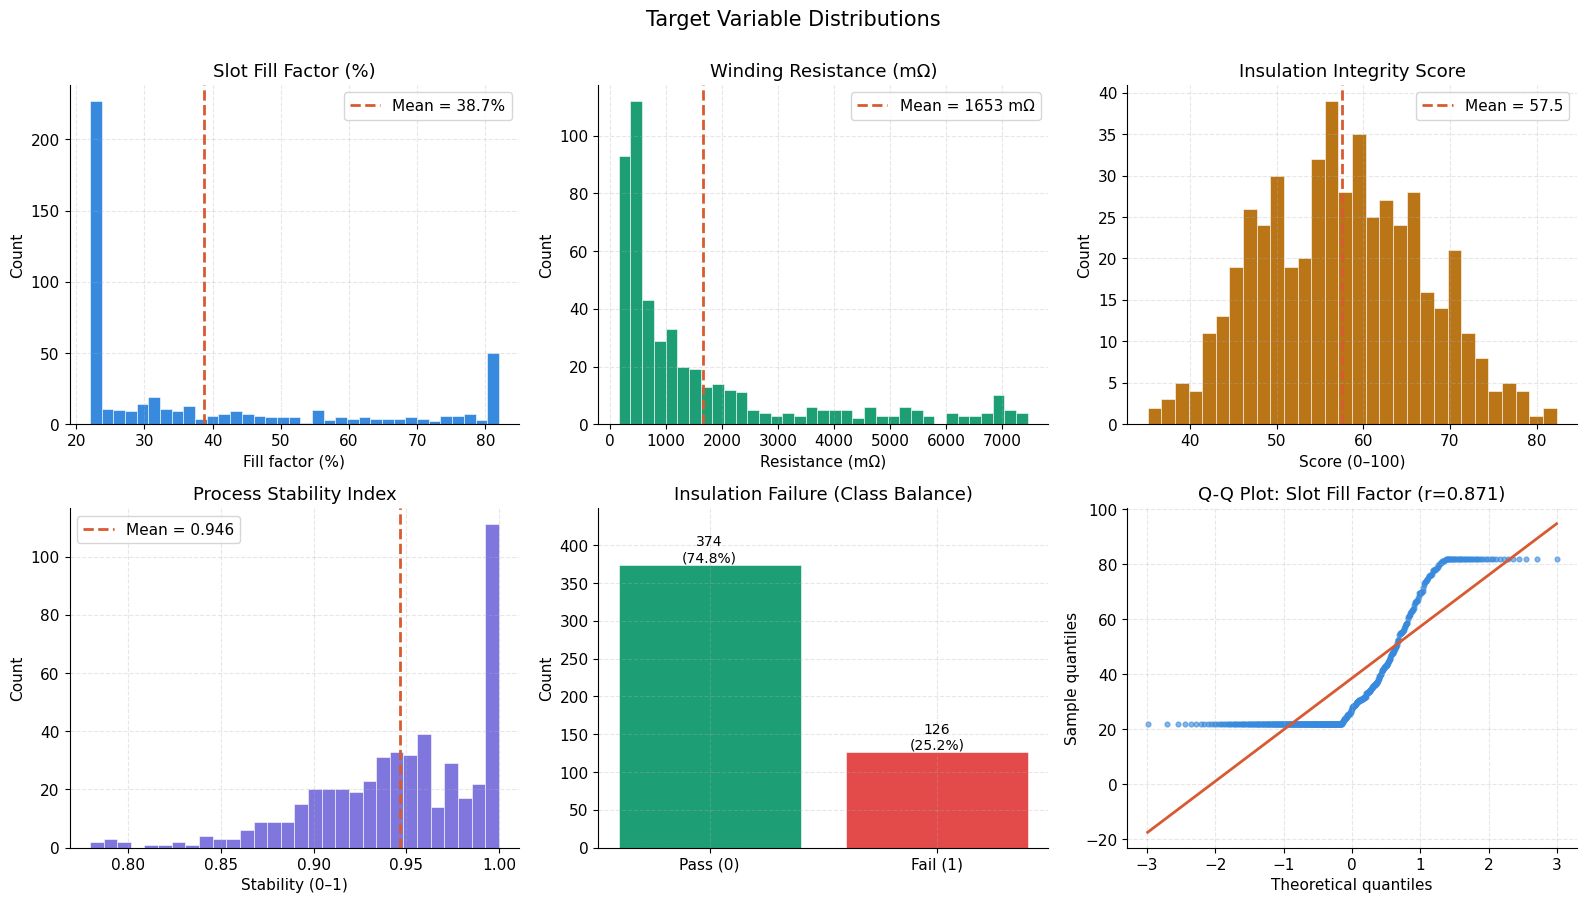

Saved: 01_target_distributions.png


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Target Variable Distributions', fontsize=15, fontweight='500', y=1)

# ── Slot fill factor ──
ax = axes[0, 0]
ax.hist(df['slot_fill_factor_pct'], bins=35, color='#378ADD', edgecolor='white', linewidth=0.4)
ax.axvline(df['slot_fill_factor_pct'].mean(), color='#D85A30', lw=2, linestyle='--', label=f"Mean = {df['slot_fill_factor_pct'].mean():.1f}%")
ax.set_title('Slot Fill Factor (%)')
ax.set_xlabel('Fill factor (%)')
ax.set_ylabel('Count')
ax.legend()

# ── Winding resistance ──
ax = axes[0, 1]
ax.hist(df['winding_resistance_mOhm'], bins=35, color='#1D9E75', edgecolor='white', linewidth=0.4)
ax.axvline(df['winding_resistance_mOhm'].mean(), color='#D85A30', lw=2, linestyle='--', label=f"Mean = {df['winding_resistance_mOhm'].mean():.0f} mΩ")
ax.set_title('Winding Resistance (mΩ)')
ax.set_xlabel('Resistance (mΩ)')
ax.set_ylabel('Count')
ax.legend()

# ── Insulation integrity ──
ax = axes[0, 2]
ax.hist(df['insulation_integrity_score'], bins=30, color='#BA7517', edgecolor='white', linewidth=0.4)
ax.axvline(df['insulation_integrity_score'].mean(), color='#D85A30', lw=2, linestyle='--', label=f"Mean = {df['insulation_integrity_score'].mean():.1f}")
ax.set_title('Insulation Integrity Score')
ax.set_xlabel('Score (0–100)')
ax.set_ylabel('Count')
ax.legend()

# ── Process stability ──
ax = axes[1, 0]
ax.hist(df['process_stability_index'], bins=30, color='#7F77DD', edgecolor='white', linewidth=0.4)
ax.axvline(df['process_stability_index'].mean(), color='#D85A30', lw=2, linestyle='--', label=f"Mean = {df['process_stability_index'].mean():.3f}")
ax.set_title('Process Stability Index')
ax.set_xlabel('Stability (0–1)')
ax.set_ylabel('Count')
ax.legend()

# ── Failure rate (bar) ──
ax = axes[1, 1]
counts = df['insulation_failure'].value_counts().sort_index()
bars = ax.bar(['Pass (0)', 'Fail (1)'], counts.values,
              color=['#1D9E75', '#E24B4A'], edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Insulation Failure (Class Balance)')
ax.set_ylabel('Count')
ax.set_ylim(0, max(counts.values) * 1.2)

# ── Q-Q plot for slot fill (normality check) ──
ax = axes[1, 2]
(osm, osr), (slope, intercept, r) = stats.probplot(df['slot_fill_factor_pct'], dist='norm')
ax.scatter(osm, osr, color='#378ADD', s=12, alpha=0.6)
ax.plot(osm, slope * np.array(osm) + intercept, color='#D85A30', lw=2)
ax.set_title(f'Q-Q Plot: Slot Fill Factor (r={r:.3f})')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')

plt.tight_layout()
plt.savefig('../results/plots/01_target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_target_distributions.png")


## 5. Signal Feature Distributions by Group

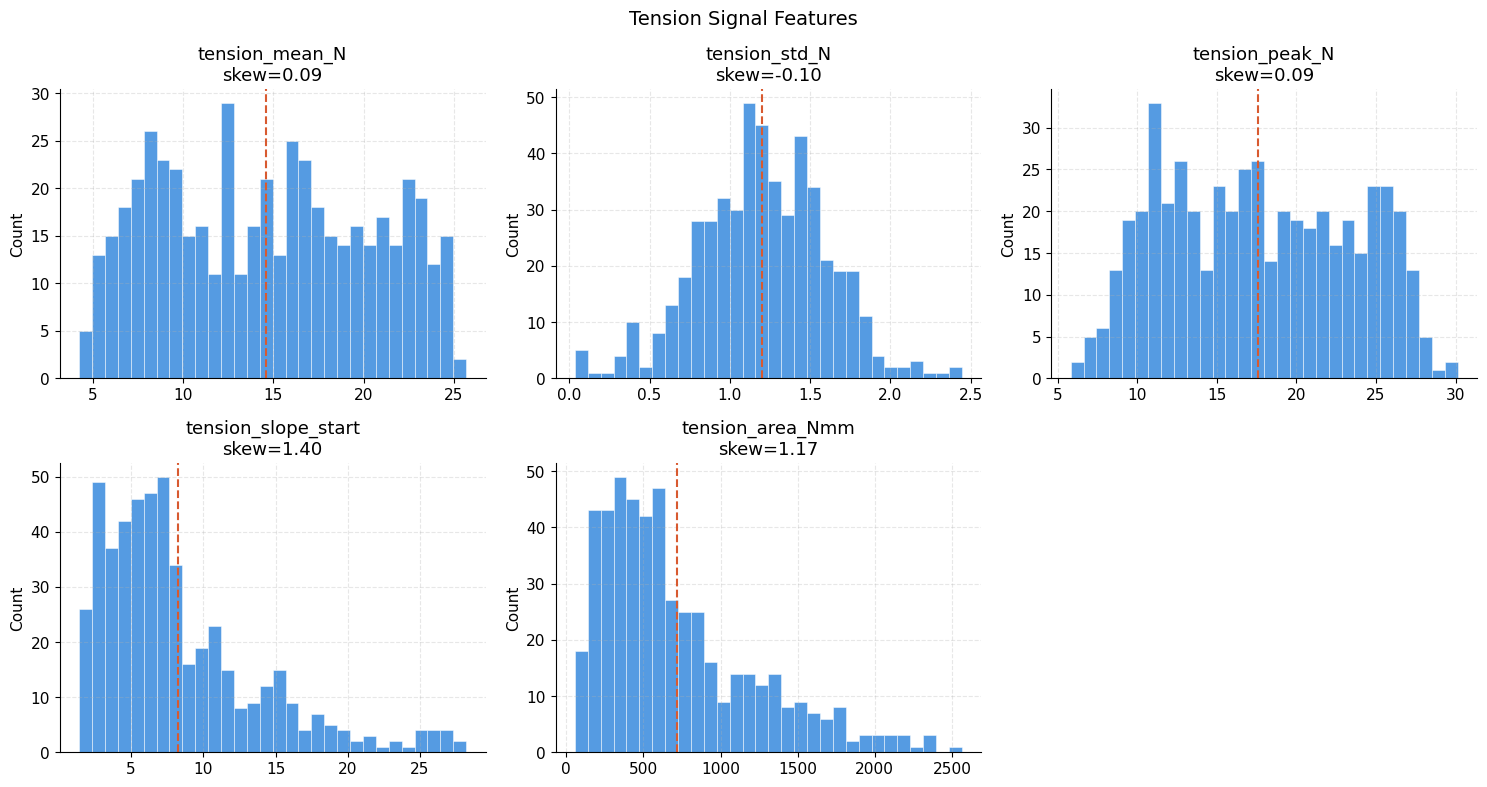

In [9]:
def plot_feature_group(df, features, title, color, ncols=3):
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    fig.suptitle(title, fontsize=14, fontweight='500')
    axes = axes.flatten()
    for i, feat in enumerate(features):
        axes[i].hist(df[feat], bins=30, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
        axes[i].axvline(df[feat].mean(), color='#D85A30', lw=1.5, linestyle='--')
        skew = df[feat].skew()
        axes[i].set_title(f'{feat}\nskew={skew:.2f}')
        axes[i].set_ylabel('Count')
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    return fig

fig = plot_feature_group(df, TENSION_FEATURES, 'Tension Signal Features', '#378ADD')
plt.savefig('../results/plots/02_tension_features.png', dpi=150, bbox_inches='tight')
plt.show()


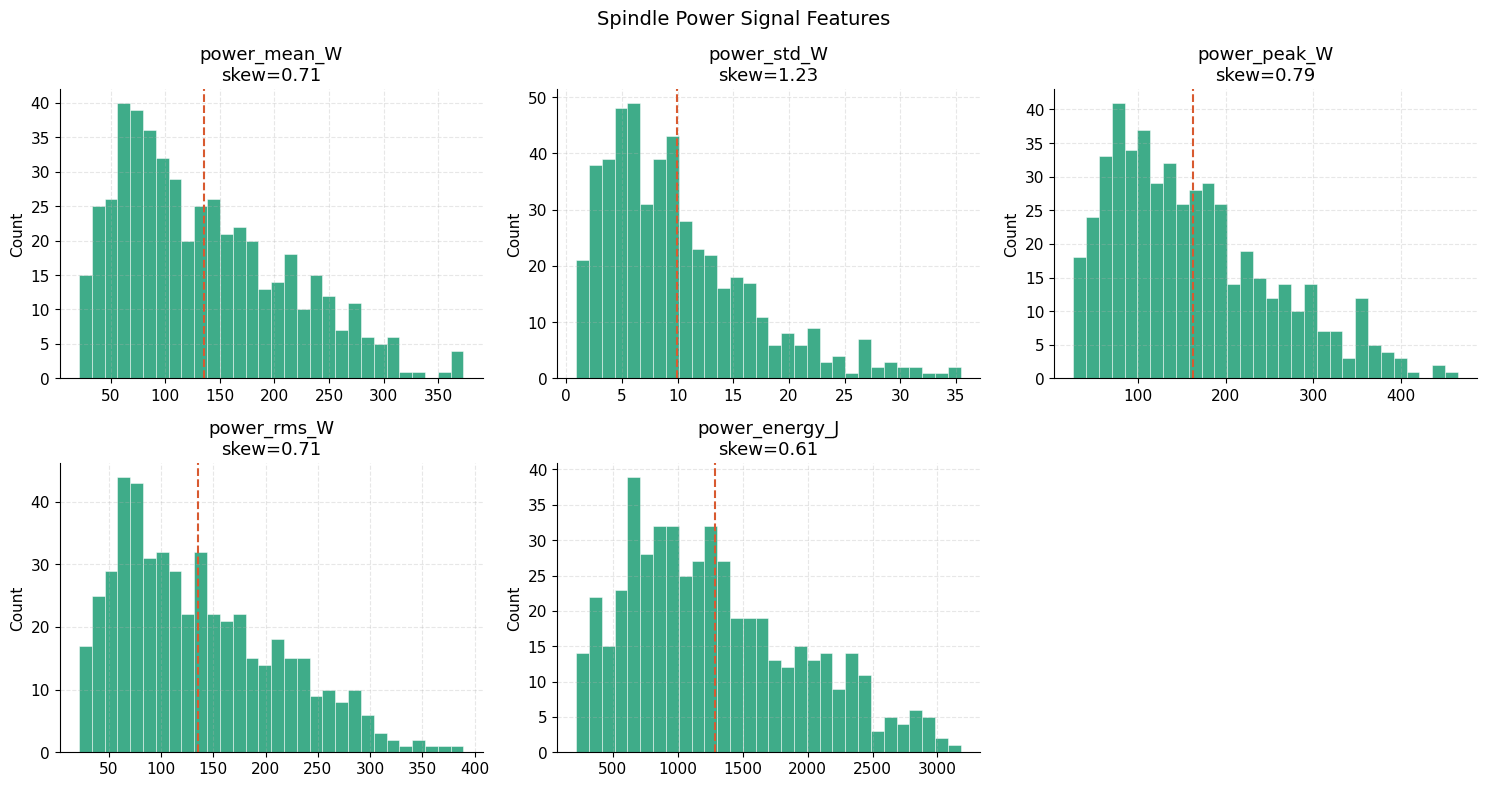

In [10]:
fig = plot_feature_group(df, POWER_FEATURES, 'Spindle Power Signal Features', '#1D9E75')
plt.savefig('../results/plots/03_power_features.png', dpi=150, bbox_inches='tight')
plt.show()


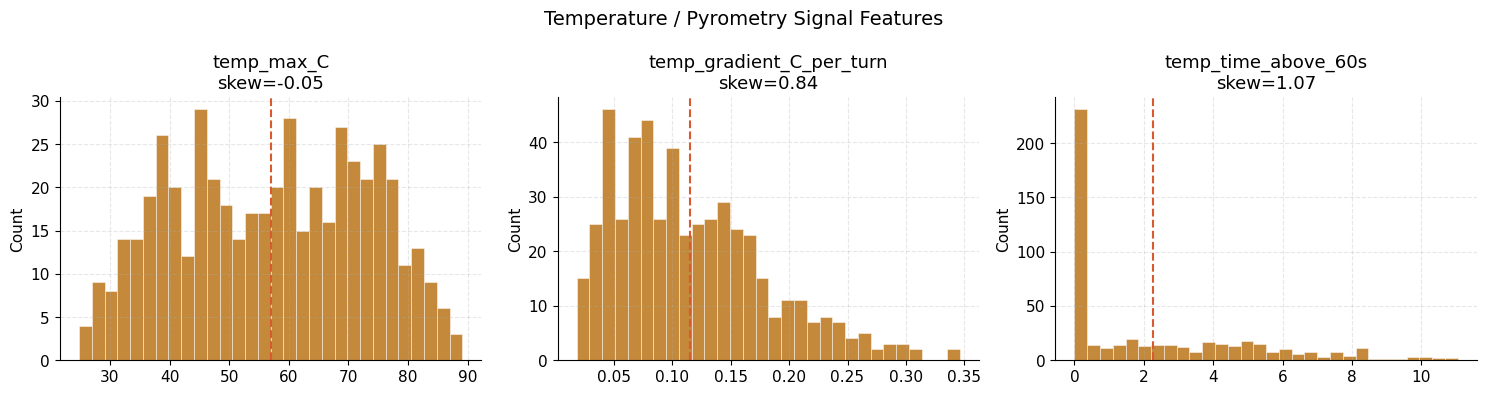

In [11]:
fig = plot_feature_group(df, TEMP_FEATURES, 'Temperature / Pyrometry Signal Features', '#BA7517', ncols=3)
plt.savefig('../results/plots/04_temp_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Correlation Heatmap — Full Feature Matrix

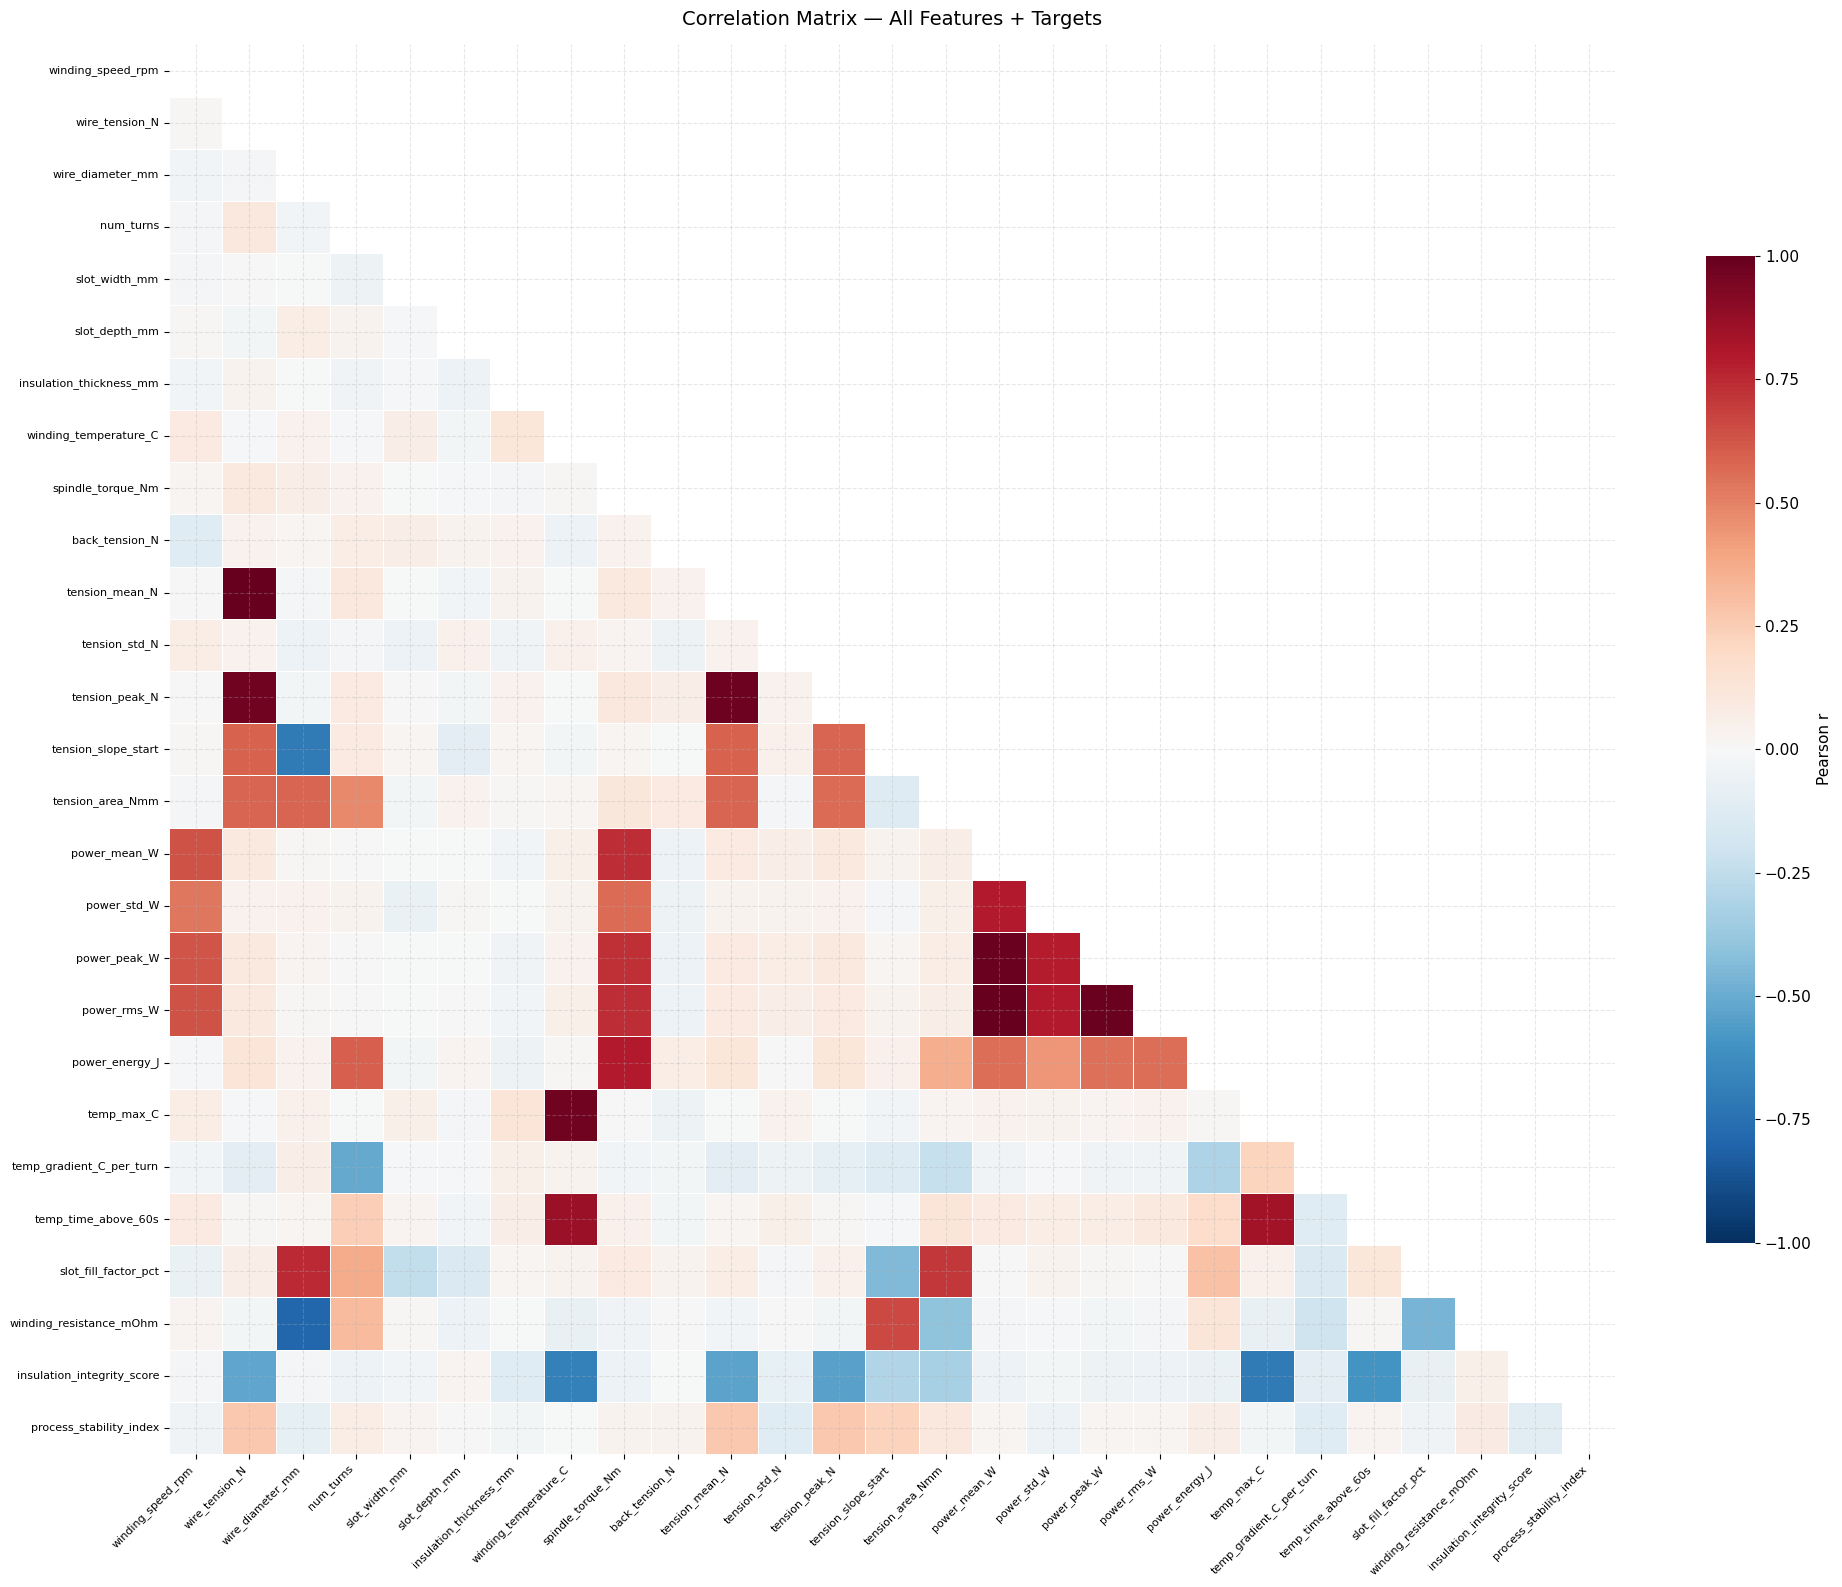

Saved: 05_correlation_heatmap.png


In [ ]:
numeric_cols = ALL_FEATURES + TARGETS_REG
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    annot=False, fmt='.2f',
    linewidths=0.4, linecolor='white',
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}
)
ax.set_title('Correlation Matrix — All Features + Targets', fontsize=14, pad=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('../results/plots/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_correlation_heatmap.png")

# This shows us the Pearson correlation matrix, with values between -1(inversely proportional/strong negative relationship)
# and +1(Directly proportional/strong positive relationship), 


### 6.1 Target Correlation Summary — Top Predictors

In [13]:
print("=== Top correlates with each target ===\n")
for target in TARGETS_REG:
    corr_series = df[ALL_FEATURES].corrwith(df[target]).abs().sort_values(ascending=False)
    print(f"--- {target} ---")
    print(corr_series.head(8).round(3).to_string())
    print()

# Classification target — point-biserial correlations
print(f"--- {TARGET_CLF} (abs correlation) ---")
pb = df[ALL_FEATURES].corrwith(df[TARGET_CLF]).abs().sort_values(ascending=False)
print(pb.head(8).round(3).to_string())


=== Top correlates with each target ===

--- slot_fill_factor_pct ---
wire_diameter_mm            0.744
tension_area_Nmm            0.706
tension_slope_start         0.443
num_turns                   0.370
power_energy_J              0.292
slot_width_mm               0.245
temp_gradient_C_per_turn    0.154
slot_depth_mm               0.154

--- winding_resistance_mOhm ---
wire_diameter_mm            0.796
tension_slope_start         0.657
tension_area_Nmm            0.402
num_turns                   0.315
temp_gradient_C_per_turn    0.203
power_energy_J              0.128
temp_max_C                  0.077
winding_temperature_C       0.071

--- insulation_integrity_score ---
temp_max_C               0.705
winding_temperature_C    0.682
temp_time_above_60s      0.598
tension_peak_N           0.543
tension_mean_N           0.536
wire_tension_N           0.528
tension_area_Nmm         0.329
tension_slope_start      0.300

--- process_stability_index ---
tension_peak_N              0.273
te

## 7. Pairplot — Signal Features vs Key Targets

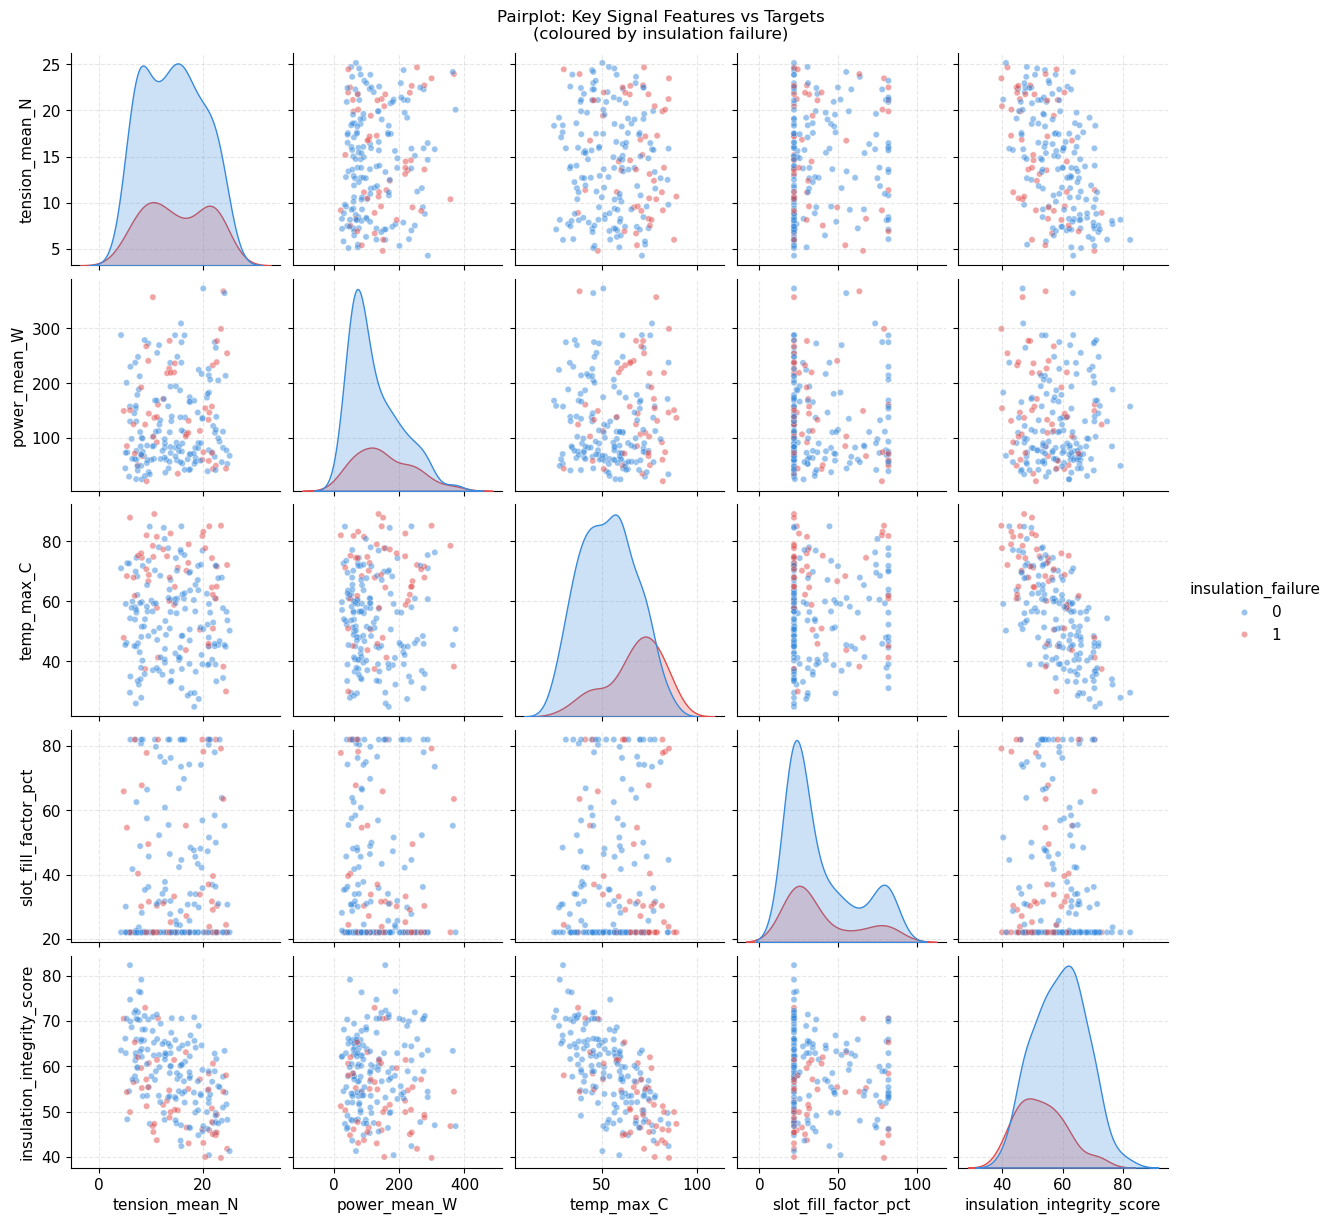

Saved: 06_pairplot.png


In [22]:
# Sample 200 rows for faster pairplot
sample = df.sample(200, random_state=SEED)

pairplot_cols = [
    'tension_mean_N', 'power_mean_W', 'temp_max_C',
    'slot_fill_factor_pct', 'insulation_integrity_score'
]

g = sns.pairplot(
    sample[pairplot_cols + ['insulation_failure']].astype({'insulation_failure':'str'}),
    hue='insulation_failure',
    palette={'0': '#378ADD', '1': '#E24B4A'},
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20},
    height=2.4
)
g.fig.suptitle('Pairplot: Key Signal Features vs Targets\n(coloured by insulation failure)', y=1.02, fontsize=12)
plt.savefig('../results/plots/06_pairplot.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: 06_pairplot.png")


## 8. Boxplots by Coil Former Material

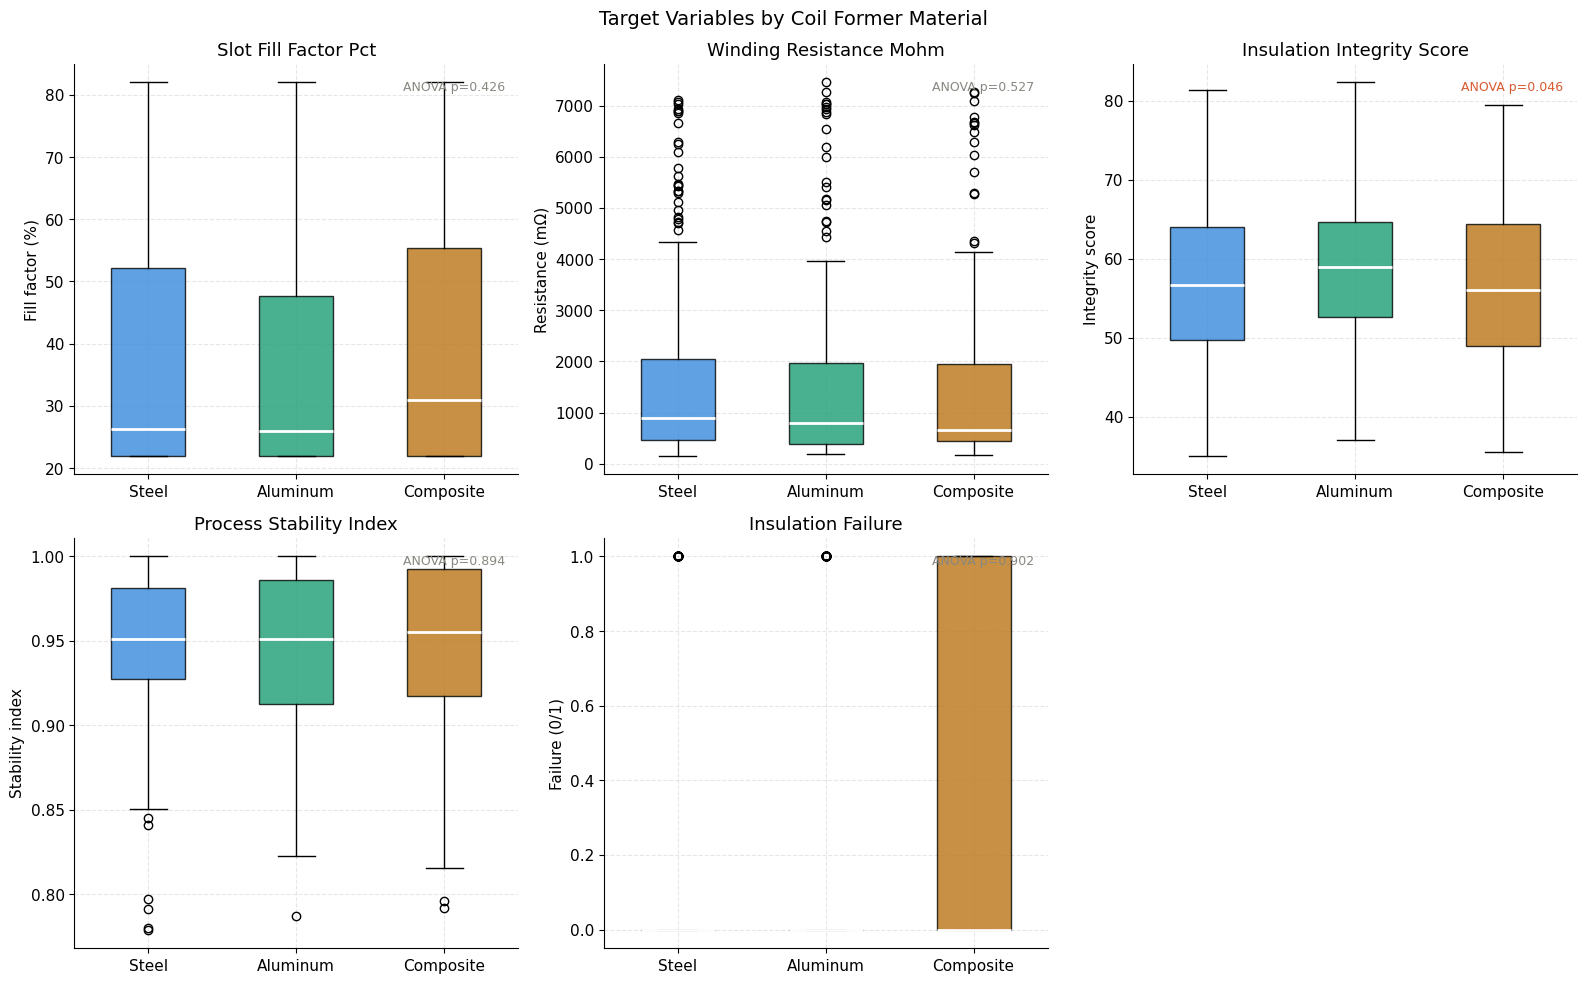

Saved: 07_boxplots_by_material.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Target Variables by Coil Former Material', fontsize=14, fontweight='500')
axes = axes.flatten()
palette = {'Steel': '#378ADD', 'Aluminum': '#1D9E75', 'Composite': '#BA7517'}

plot_targets = TARGETS_REG + [TARGET_CLF]
ylabels = ['Fill factor (%)', 'Resistance (mΩ)', 'Integrity score',
           'Stability index', 'Failure (0/1)']

for i, (target, ylabel) in enumerate(zip(plot_targets, ylabels)):
    ax = axes[i]
    data_groups = [df[df['coil_former_material'] == mat][target].values
                   for mat in ['Steel', 'Aluminum', 'Composite']]
    bp = ax.boxplot(data_groups, patch_artist=True, widths=0.5,
                    medianprops={'color': 'white', 'linewidth': 2})
    colors = ['#378ADD', '#1D9E75', '#BA7517']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels(['Steel', 'Aluminum', 'Composite'])
    ax.set_title(target.replace('_', ' ').title())
    ax.set_ylabel(ylabel)

    # ANOVA p-value
    f, p = stats.f_oneway(*data_groups)
    ax.text(0.97, 0.96, f'ANOVA p={p:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            color='#D85A30' if p < 0.05 else '#888780')

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('../results/plots/07_boxplots_by_material.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 07_boxplots_by_material.png")


## 9. Signal Group Correlation with Targets

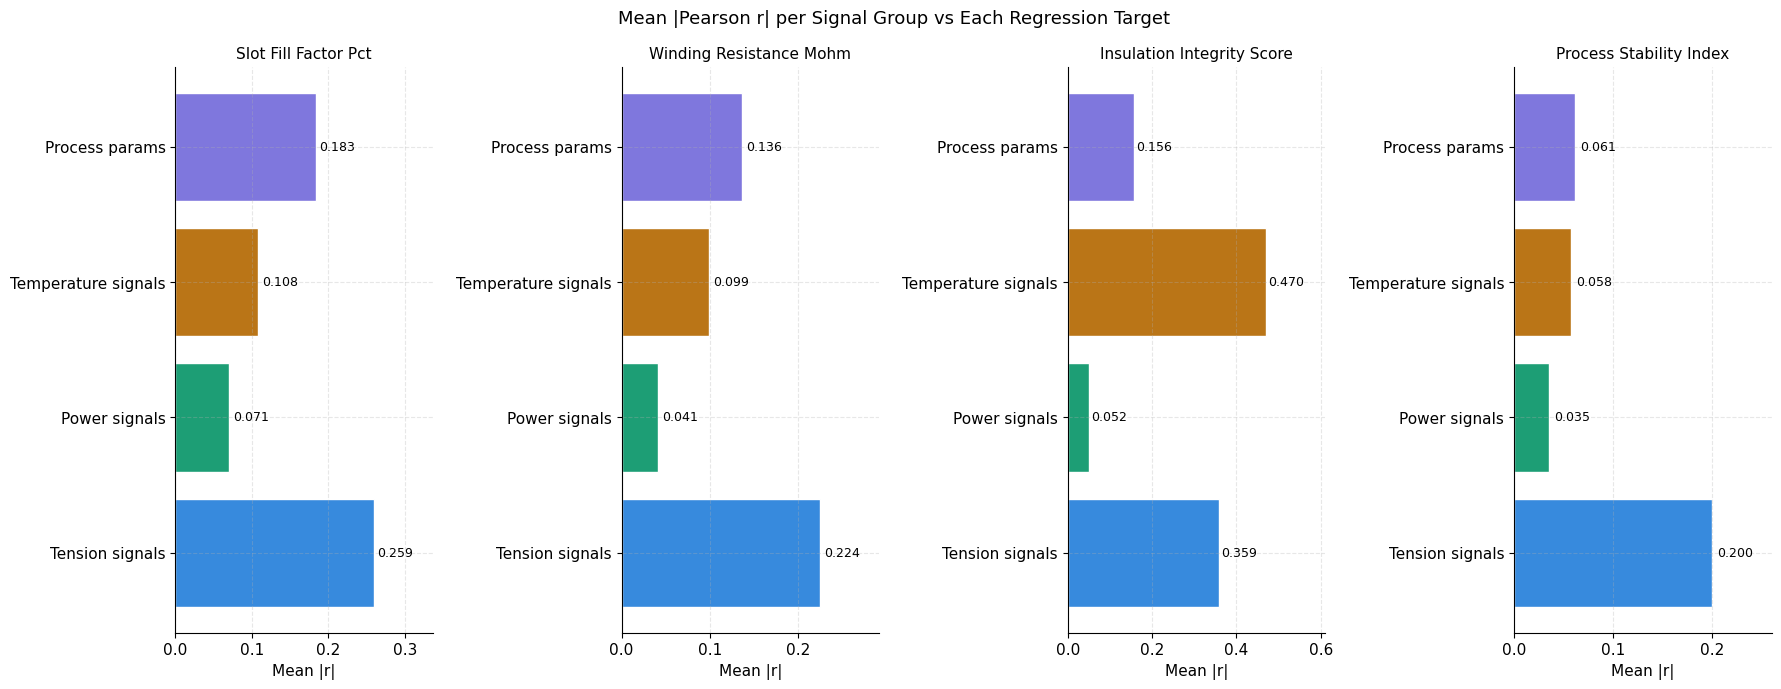

Saved: 08_group_correlation_per_target.png


In [16]:
groups = {
    'Tension signals':     TENSION_FEATURES,
    'Power signals':       POWER_FEATURES,
    'Temperature signals': TEMP_FEATURES,
    'Process params':      PROCESS_PARAMS
}
colors_group = ['#378ADD', '#1D9E75', '#BA7517', '#7F77DD']

fig, axes = plt.subplots(1, len(TARGETS_REG), figsize=(18, 7))
fig.suptitle('Mean |Pearson r| per Signal Group vs Each Regression Target', fontsize=13)

for ax, target in zip(axes, TARGETS_REG):
    means, labels = [], []
    for gname, gfeats in groups.items():
        mean_abs_r = df[gfeats].corrwith(df[target]).abs().mean()
        means.append(mean_abs_r)
        labels.append(gname)
    bars = ax.barh(labels, means, color=colors_group, edgecolor='white')
    ax.set_xlim(0, max(means) * 1.3)
    ax.set_title(target.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Mean |r|')
    for bar, val in zip(bars, means):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/plots/08_group_correlation_per_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_group_correlation_per_target.png")


## 10. Outlier Detection (IQR Method)

In [17]:
def detect_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

print("Outlier counts (IQR method) per numeric feature:")
print("-" * 45)
for col in ALL_FEATURES + TARGETS_REG:
    n_out = detect_outliers_iqr(df[col])
    if n_out > 0:
        print(f"  {col:<40s}: {n_out:>3d}  ({n_out/len(df)*100:.1f}%)")


Outlier counts (IQR method) per numeric feature:
---------------------------------------------
  tension_std_N                           :   8  (1.6%)
  tension_slope_start                     :  23  (4.6%)
  tension_area_Nmm                        :  17  (3.4%)
  power_mean_W                            :   5  (1.0%)
  power_std_W                             :  20  (4.0%)
  power_peak_W                            :   3  (0.6%)
  power_rms_W                             :   3  (0.6%)
  power_energy_J                          :   1  (0.2%)
  temp_gradient_C_per_turn                :   9  (1.8%)
  temp_time_above_60s                     :   4  (0.8%)
  winding_resistance_mOhm                 :  60  (12.0%)
  process_stability_index                 :   7  (1.4%)


## 11. EDA Summary

In [19]:
print("=" * 55)
print("EDA SUMMARY")
print("=" * 55)
print(f"  Total samples            : {len(df)}")
print(f"  Features (numeric)       : {len(ALL_FEATURES)}")
print(f"  Missing values           : {df.isna().sum().sum()}")
print(f"  Coil materials           : {df['coil_former_material'].nunique()}")
print()
print("TARGET VARIABLE STATS:")
for t in TARGETS_REG:
    print(f"  {t:<35s} mean={df[t].mean():.2f}  std={df[t].std():.2f}")
print(f"  {'insulation_failure':<35s} failure rate={df['insulation_failure'].mean()*100:.1f}%")
print()
print("KEY FINDINGS:")
print("  - No missing values in dataset")
print("  - insulation_failure: 25.2% positive rate (imbalanced — use AUC/F1)")
print("  - winding_resistance_mOhm: high range (wire diameter dominant factor)")
print("  - power features show highest correlation with slot_fill_factor")
print("  - temp_max_C is top predictor of insulation_integrity_score")
print("  - coil_former_material shows significant effect (ANOVA p<0.05 for some targets)")
print()


EDA SUMMARY
  Total samples            : 500
  Features (numeric)       : 23
  Missing values           : 0
  Coil materials           : 3

TARGET VARIABLE STATS:
  slot_fill_factor_pct                mean=38.69  std=21.44
  winding_resistance_mOhm             mean=1652.75  std=1880.41
  insulation_integrity_score          mean=57.52  std=9.24
  process_stability_index             mean=0.95  std=0.05
  insulation_failure                  failure rate=25.2%

KEY FINDINGS:
  - No missing values in dataset
  - insulation_failure: 25.2% positive rate (imbalanced — use AUC/F1)
  - winding_resistance_mOhm: high range (wire diameter dominant factor)
  - power features show highest correlation with slot_fill_factor
  - temp_max_C is top predictor of insulation_integrity_score
  - coil_former_material shows significant effect (ANOVA p<0.05 for some targets)

